# Tasks 4 & 5: Volatility Analysis + Portfolio Construction

**Task 4:** Risk profiling via log returns, rolling 30-day σ, and STL decomposition.

**Task 5:** ₹10,00,000 allocated across 7 stocks using four complementary strategies:
- **A** — Forecast-Guided: proportional to predicted positive return
- **B** — Inverse-Volatility: 1/σ weighting (lower risk → larger position)
- **C** — Inverse-Correlation: stocks less correlated with the portfolio get more weight
- **D** — Sector Momentum: 30-day trailing returns signal where capital rotates

**Actual trades** used the A+B blend (executed on StockGro on 11 May 2026).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from statsmodels.tsa.seasonal import STL
import pickle, warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

STOCKS = {
    'RELIANCE.NS'   : 'Reliance',
    'HDFCBANK.NS'   : 'HDFC Bank',
    'INFY.NS'       : 'Infosys',
    'SUNPHARMA.NS'  : 'Sun Pharma',
    'MARUTI.NS'     : 'Maruti',
    'HINDUNILVR.NS' : 'HUL',
    'TATASTEEL.NS'  : 'Tata Steel',
}
TOTAL_CAPITAL = 1_000_000   # ₹10,00,000
TEST_START    = '2025-07-01'

close_clean = pd.read_csv('data/close_prices_clean.csv', index_col=0, parse_dates=True)

with open('data/arima_forecasts.pkl',   'rb') as f: arima_5day   = pickle.load(f)
with open('data/prophet_forecasts.pkl', 'rb') as f: prophet_5day = pickle.load(f)

print('✅ Data loaded')

✅ Data loaded


## Task 4: Volatility Estimation

In [2]:
# ── LOG RETURNS ────────────────────────────────────────────────────────────────
# Log return: ln(P_t / P_{t-1})

log_returns = np.log(close_clean / close_clean.shift(1)).dropna()

# Summary statistics
print('Log Return Statistics:')
stats = log_returns.describe().T
stats['annualized_std'] = stats['std'] * np.sqrt(252)
stats['annualized_return'] = stats['mean'] * 252

summary_table = stats[['mean', 'std', 'annualized_return', 'annualized_std']].round(4)
summary_table.index = [STOCKS.get(s, s) for s in summary_table.index]
print(summary_table)

Log Return Statistics:
              mean     std  annualized_return  annualized_std
HDFC Bank   0.0003  0.0134             0.0784          0.2124
HUL         0.0000  0.0127             0.0086          0.2013
Infosys     0.0003  0.0152             0.0775          0.2411
Maruti      0.0007  0.0146             0.1664          0.2318
Reliance    0.0004  0.0143             0.1094          0.2270
Sun Pharma  0.0009  0.0131             0.2269          0.2085
Tata Steel  0.0009  0.0208             0.2360          0.3307



Most Recent 30-Day Annualized Volatility:
  Tata Steel     : 22.06%  ██████████████████████
  Infosys        : 19.29%  ███████████████████
  HUL            : 19.28%  ███████████████████
  Sun Pharma     : 15.07%  ███████████████
  Maruti         : 14.67%  ██████████████
  Reliance       : 12.14%  ████████████
  HDFC Bank      : 11.49%  ███████████


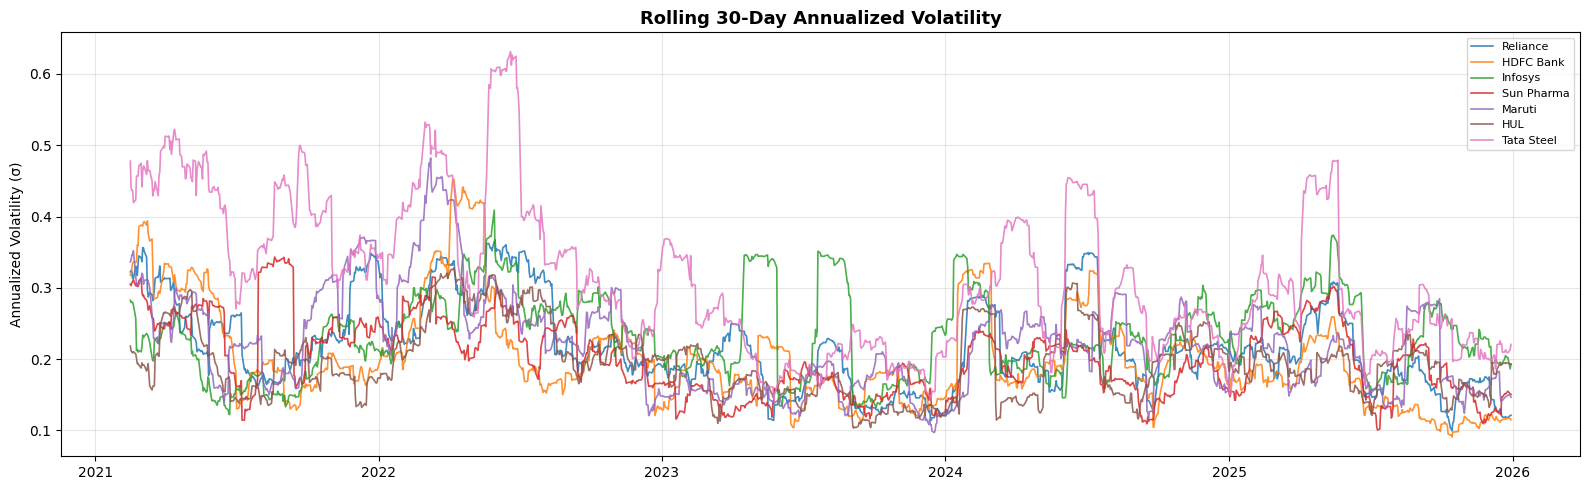

In [3]:
# ── ROLLING VOLATILITY (30-day window) ────────────────────────────────────────

rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252)

# Use the MOST RECENT 30-day volatility as our estimate for near-term risk
recent_vol = rolling_vol.iloc[-1]   # last row = most recent day
recent_vol.index = [STOCKS.get(s, s) for s in recent_vol.index]

print('\nMost Recent 30-Day Annualized Volatility:')
for name, vol in recent_vol.sort_values(ascending=False).items():
    bar = '█' * int(vol * 100)
    print(f'  {name:15s}: {vol:.2%}  {bar}')

# Plot rolling volatility
fig, ax = plt.subplots(figsize=(16, 5))
colors = plt.cm.tab10.colors
for i, sym in enumerate(STOCKS.keys()):
    ax.plot(rolling_vol.index, rolling_vol[sym],
            label=STOCKS[sym], color=colors[i], linewidth=1.2, alpha=0.85)
ax.set_title('Rolling 30-Day Annualized Volatility', fontsize=13, fontweight='bold')
ax.set_ylabel('Annualized Volatility (σ)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('results/04_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

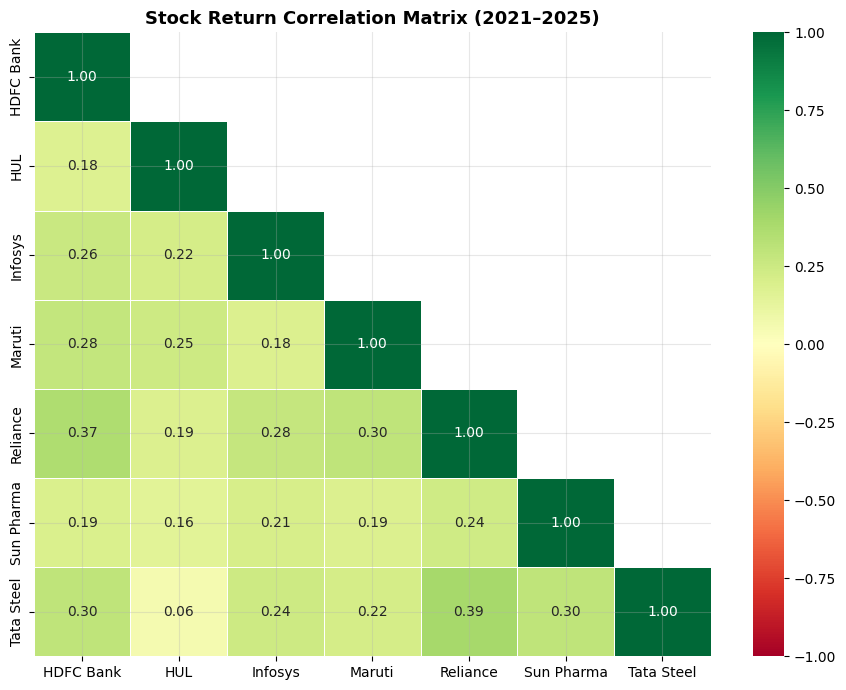

Green = low/negative correlation = good for diversification
Red   = high positive correlation = stocks move together (less diversification benefit)


In [4]:
# ── CORRELATION MATRIX ────────────────────────────────────────────────────────
# +1 = move in perfect tandem | 0 = no relation | -1 = move opposite

corr_matrix = log_returns.corr()
corr_matrix.columns = [STOCKS.get(s, s) for s in corr_matrix.columns]
corr_matrix.index   = corr_matrix.columns

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # hide upper triangle (redundant)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, mask=mask)
ax.set_title('Stock Return Correlation Matrix (2021–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Green = low/negative correlation = good for diversification')
print('Red   = high positive correlation = stocks move together (less diversification benefit)')

corr_matrix.to_csv('results/04_correlation_matrix.csv')

## STL Decomposition
Separates each price series into trend, seasonal (period=252 trading days), and residual components.
Trend strength is measured as the fraction of total variance explained by the trend component.

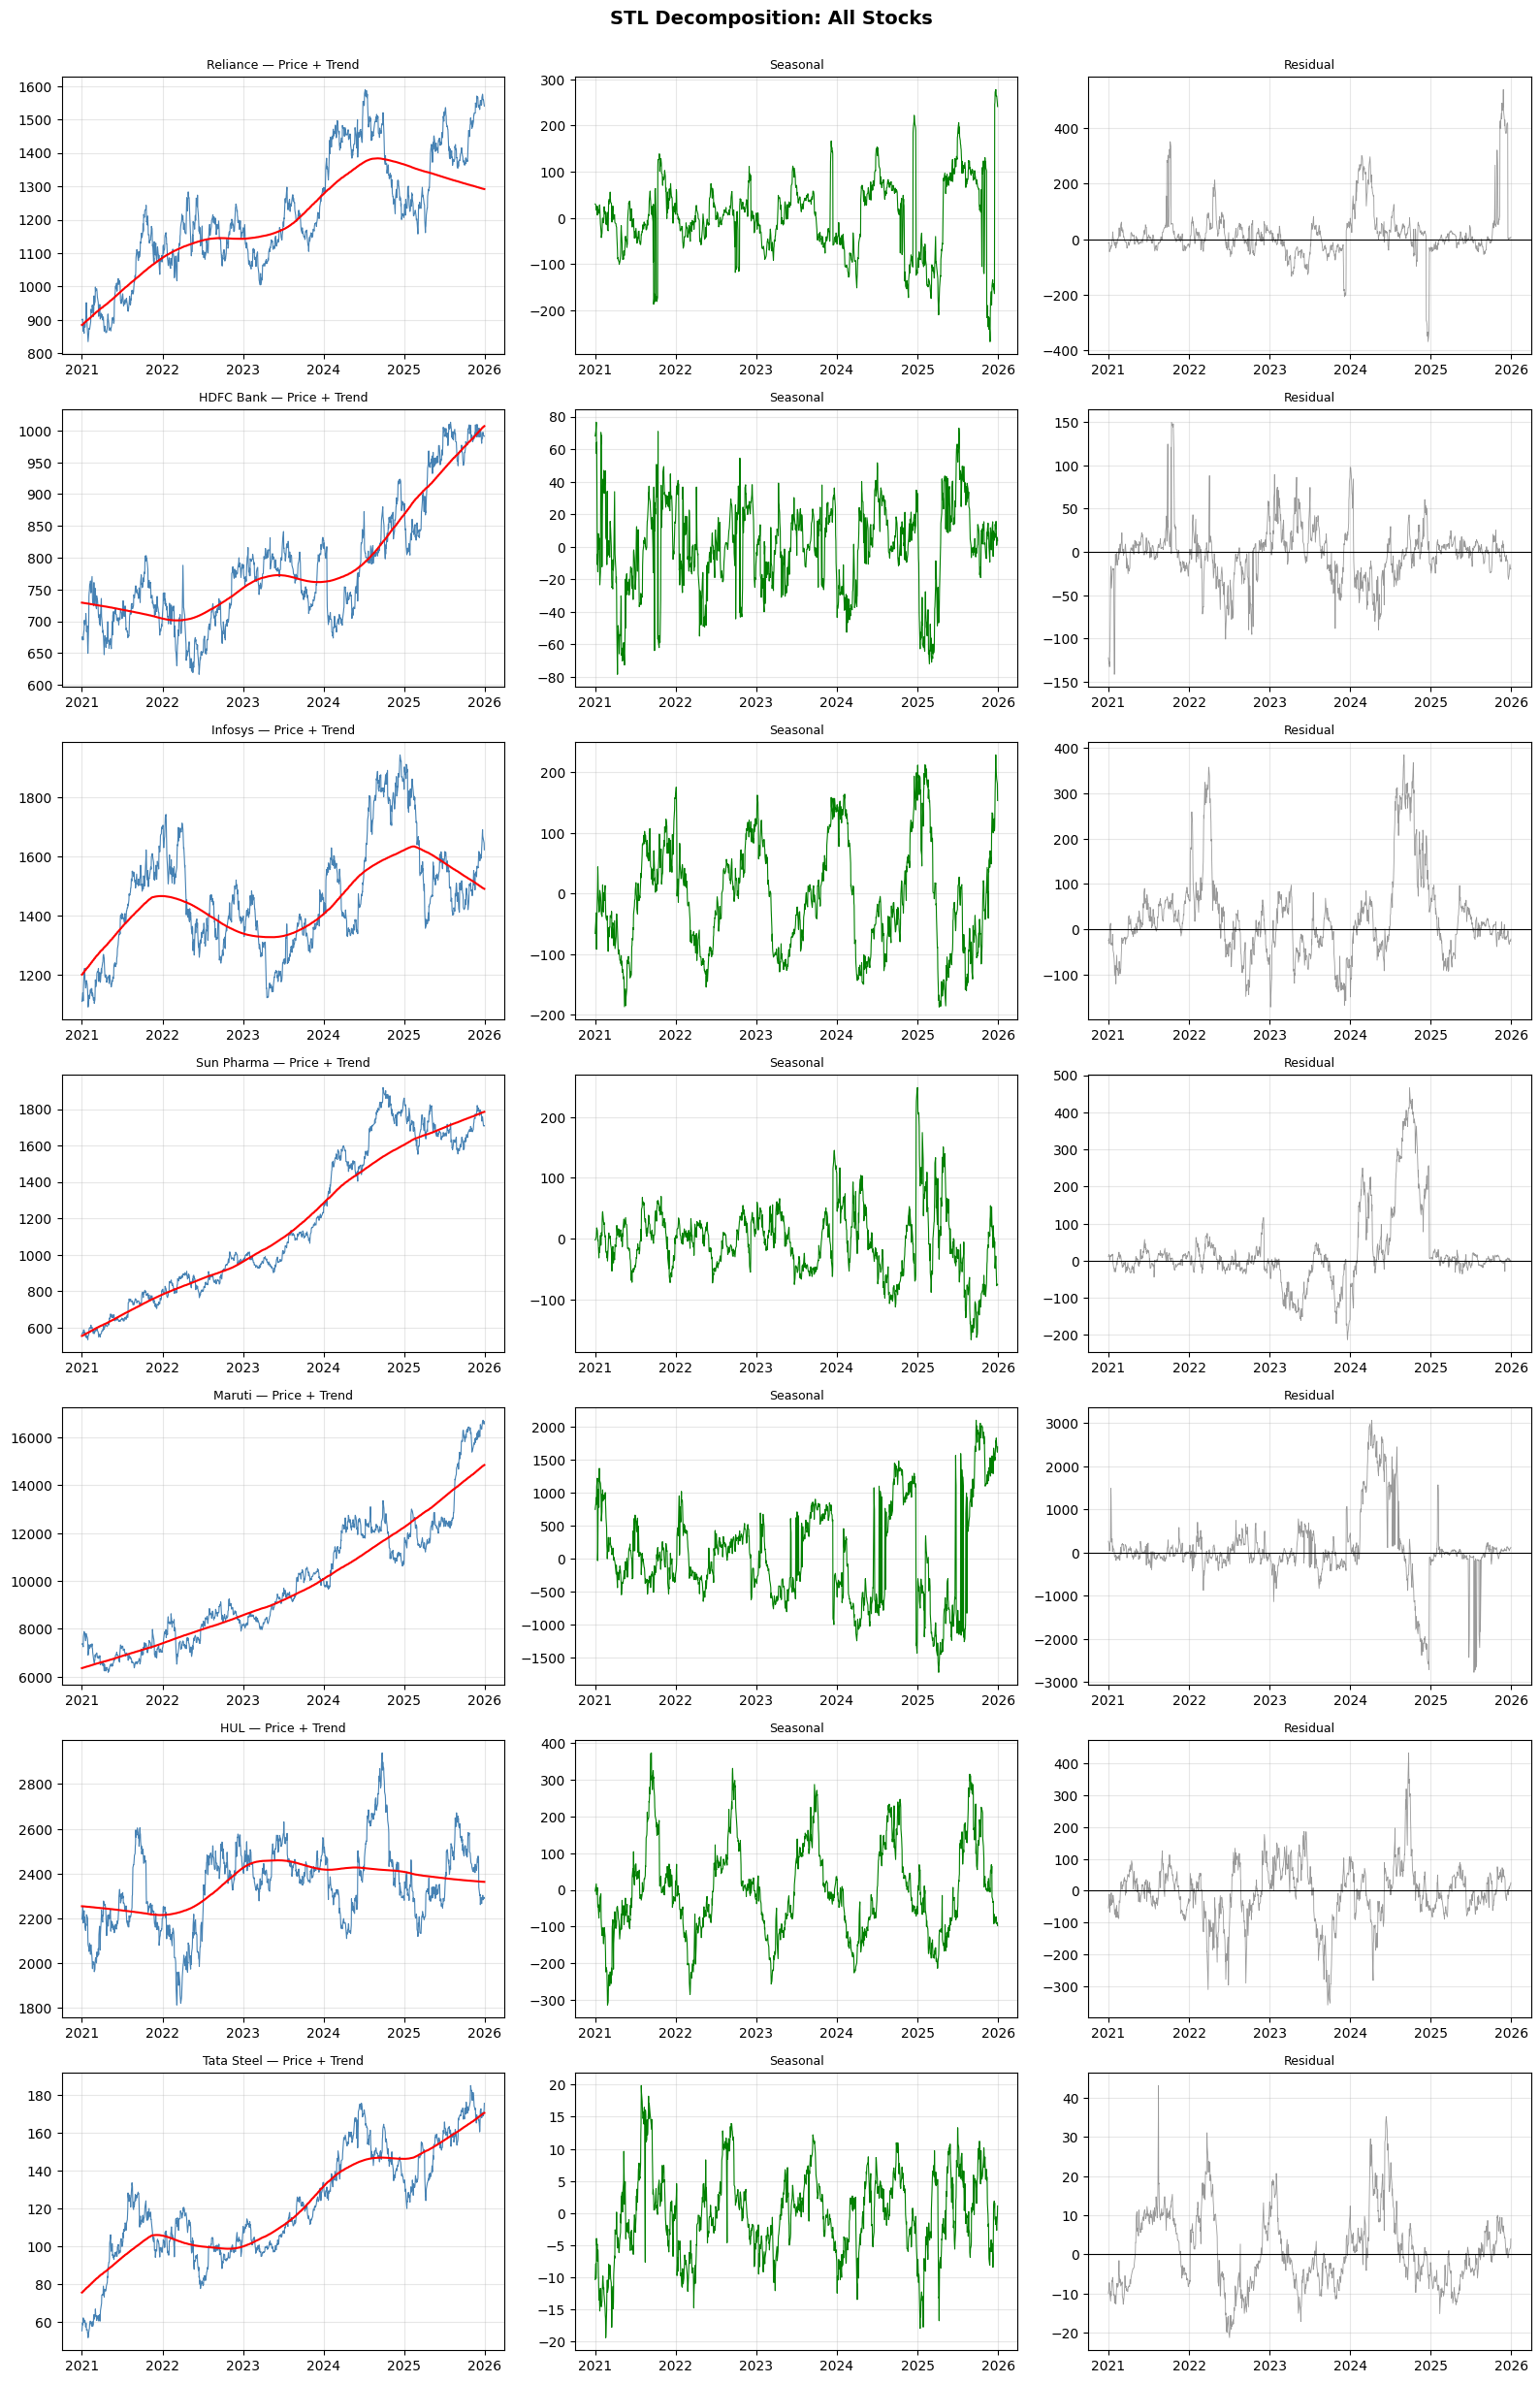


Trend Profiles:
  Reliance       : ↑  +45.9%  |  Trend strength: 60.0%  |  Recent daily: -0.27
  HDFC Bank      : ↑  +38.1%  |  Trend strength: 75.4%  |  Recent daily: +0.53
  Infosys        : ↑  +24.1%  |  Trend strength: 32.4%  |  Recent daily: -0.73
  Sun Pharma     : ↑ +222.5%  |  Trend strength: 84.3%  |  Recent daily: +0.70
  Maruti         : ↑ +133.1%  |  Trend strength: 86.0%  |  Recent daily: +10.93
  HUL            : ↑   +4.8%  |  Trend strength: 21.8%  |  Recent daily: -0.11
  Tata Steel     : ↑ +125.7%  |  Trend strength: 75.1%  |  Recent daily: +0.13


In [5]:
# ── STL DECOMPOSITION ────────────────────────────────────────────────────────

trend_profiles = {}

fig, axes = plt.subplots(len(STOCKS), 3, figsize=(16, 3.5 * len(STOCKS)))

for i, (sym, name) in enumerate(STOCKS.items()):
    series = close_clean[sym].dropna().sort_index()
    # STL needs period ≥ 2. period=252 = 1 year of trading days
    stl    = STL(series, period=252, seasonal=13, robust=True)
    result = stl.fit()
    
    # Trend direction and strength
    trend   = result.trend.dropna()
    t_start = trend.iloc[0]
    t_end   = trend.iloc[-1]
    t_pct   = (t_end - t_start) / t_start * 100
    t_str   = trend.var() / series.var() * 100   # % of variance explained by trend
    
    trend_profiles[sym] = {
        'name'           : name,
        'trend_return_pct': round(t_pct, 1),
        'direction'      : 'Up' if t_pct > 0 else 'Down',
        'trend_strength' : round(t_str, 1),
        'recent_trend'   : trend.iloc[-20:].diff().mean()  # avg recent daily trend
    }
    
    axes[i, 0].plot(series, color='steelblue', linewidth=0.8)
    axes[i, 0].plot(result.trend, color='red', linewidth=1.5)
    axes[i, 0].set_title(f'{name} — Price + Trend', fontsize=9)
    
    axes[i, 1].plot(result.seasonal, color='green', linewidth=0.8)
    axes[i, 1].set_title('Seasonal', fontsize=9)
    
    axes[i, 2].plot(result.resid, color='gray', linewidth=0.6, alpha=0.8)
    axes[i, 2].axhline(0, color='black', linewidth=0.8)
    axes[i, 2].set_title('Residual', fontsize=9)

plt.suptitle('STL Decomposition: All Stocks', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('results/04_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTrend Profiles:')
for sym, p in trend_profiles.items():
    arrow = '↑' if p['direction'] == 'Up' else '↓'
    print(f'  {p["name"]:15s}: {arrow} {p["trend_return_pct"]:+6.1f}%  |  Trend strength: {p["trend_strength"]:.1f}%  |  Recent daily: {p["recent_trend"]:+.2f}')

## Task 5: Portfolio Construction

In [6]:
# ── EXTRACT PREDICTED RETURNS (for Strategy A) ────────────────────────────────
# We ensemble ARIMA and Prophet forecasts for Day 1 and Day 2

print('=== Predicted Returns (ARIMA + Prophet Ensemble) ===\n')
predicted_returns = {}  # dict: sym → predicted % gain over 2 days

for sym, name in STOCKS.items():
    last_price = close_clean[sym].dropna().iloc[-1]
    
    # ARIMA Day2 forecast
    arima_day2   = float(arima_5day[sym]['forecast'].iloc[1])   # index 1 = Day 2
    
    # Prophet Day2 forecast
    prophet_day2 = float(prophet_5day[sym]['yhat'].iloc[1])
    
    # Ensemble: simple average of the two models
    ensemble_day2  = (arima_day2 + prophet_day2) / 2
    predicted_pct  = (ensemble_day2 - last_price) / last_price * 100
    
    predicted_returns[sym] = predicted_pct
    signal = '🟢 BUY' if predicted_pct > 0 else '🔴 AVOID'
    print(f'  {name:15s}: Last=₹{last_price:.1f}  Day2 Ensemble=₹{ensemble_day2:.1f}  Predicted={predicted_pct:+.2f}%  {signal}')

=== Predicted Returns (ARIMA + Prophet Ensemble) ===

  Reliance       : Last=₹1539.8  Day2 Ensemble=₹1540.1  Predicted=+0.02%  🟢 BUY
  HDFC Bank      : Last=₹990.9  Day2 Ensemble=₹999.4  Predicted=+0.86%  🟢 BUY
  Infosys        : Last=₹1621.6  Day2 Ensemble=₹1586.1  Predicted=-2.19%  🔴 AVOID
  Sun Pharma     : Last=₹1709.1  Day2 Ensemble=₹1724.8  Predicted=+0.92%  🟢 BUY
  Maruti         : Last=₹16647.0  Day2 Ensemble=₹16623.4  Predicted=-0.14%  🔴 AVOID
  HUL            : Last=₹2290.2  Day2 Ensemble=₹2328.3  Predicted=+1.66%  🟢 BUY
  Tata Steel     : Last=₹175.8  Day2 Ensemble=₹174.6  Predicted=-0.66%  🔴 AVOID


In [7]:
# ── STRATEGY A: FORECAST-GUIDED ALLOCATION ─────────────────────────────────────
# Weight each stock proportionally to its predicted positive return.
# Stocks predicted to fall get ZERO weight (we don't short in this project).

# Clip negative returns to 0 (we don't invest in predicted losers)
pos_returns = {sym: max(ret, 0) for sym, ret in predicted_returns.items()}
total_pos   = sum(pos_returns.values())

if total_pos == 0:
    # If all forecasts are negative, distribute equally among least-negative
    top3 = sorted(predicted_returns.items(), key=lambda x: -x[1])[:3]
    pos_returns = {sym: 1/3 for sym, _ in top3}
    total_pos = 1.0

weights_A = {sym: pos_returns[sym] / total_pos for sym in STOCKS.keys()}

print('Strategy A weights (Forecast-Guided):')
for sym, w in sorted(weights_A.items(), key=lambda x: -x[1]):
    print(f'  {STOCKS[sym]:15s}: {w:.2%}')

Strategy A weights (Forecast-Guided):
  HUL            : 48.13%
  Sun Pharma     : 26.59%
  HDFC Bank      : 24.75%
  Reliance       : 0.52%
  Infosys        : 0.00%
  Maruti         : 0.00%
  Tata Steel     : 0.00%


In [8]:
# ── STRATEGY B: VOLATILITY-AWARE SIZING ─────────────────────────────────────
# Weight = 1/σ (inverse of volatility)
# More volatile stocks → smaller weight | Stable stocks → larger weight
# Then normalize so all weights sum to 1.

# Use recent_vol from Task 4
vol_dict = dict(zip([s for s in STOCKS.keys()],
                    [rolling_vol[sym].iloc[-1] for sym in STOCKS.keys()]))

inv_vol     = {sym: 1 / vol for sym, vol in vol_dict.items()}
sum_inv_vol = sum(inv_vol.values())
weights_B   = {sym: inv_vol[sym] / sum_inv_vol for sym in STOCKS.keys()}

print('Strategy B weights (Volatility-Aware, 1/σ):')
for sym, w in sorted(weights_B.items(), key=lambda x: -x[1]):
    print(f'  {STOCKS[sym]:15s}: {w:.2%}  (σ={vol_dict[sym]:.2%})')

Strategy B weights (Volatility-Aware, 1/σ):
  HDFC Bank      : 19.21%  (σ=11.49%)
  Reliance       : 18.19%  (σ=12.14%)
  Maruti         : 15.05%  (σ=14.67%)
  Sun Pharma     : 14.65%  (σ=15.07%)
  HUL            : 11.45%  (σ=19.28%)
  Infosys        : 11.44%  (σ=19.29%)
  Tata Steel     : 10.01%  (σ=22.06%)


## Strategy C: Correlation-Based Diversification
Stocks with lower average absolute correlation to the rest of the portfolio get higher weight.
A stock that moves in lockstep with all others adds no diversification benefit.

In [ ]:
# ── STRATEGY C: INVERSE-CORRELATION WEIGHTING ────────────────────────────────
# The correlation matrix is already computed above (corr_matrix uses renamed index).
# We need the raw-symbol version from log_returns directly.

corr_raw = log_returns.corr()   # symbols as index/columns

avg_abs_corr = {}
for sym in STOCKS:
    others = [s for s in STOCKS if s != sym]
    avg_abs_corr[sym] = corr_raw.loc[sym, others].abs().mean()

inv_corr  = {sym: 1 / avg_abs_corr[sym] for sym in STOCKS}
sum_ic    = sum(inv_corr.values())
weights_C = {sym: inv_corr[sym] / sum_ic for sym in STOCKS}

print('Strategy C weights (Correlation-Based Diversification):')
for sym, w in sorted(weights_C.items(), key=lambda x: -x[1]):
    print(f'  {STOCKS[sym]:15s}: {w:.2%}  (avg |ρ| with others = {avg_abs_corr[sym]:.3f})')


## Strategy D: Sector Momentum Rotation
30-day trailing returns are used as a momentum signal.
Stocks with positive recent momentum get proportionally more capital; those with negative momentum
are floored at 1% (kept in portfolio for diversification, not zeroed out).

In [ ]:
# ── STRATEGY D: SECTOR MOMENTUM ──────────────────────────────────────────────

SECTORS = {
    'RELIANCE.NS'   : 'Energy',
    'HDFCBANK.NS'   : 'Banking',
    'INFY.NS'       : 'IT',
    'SUNPHARMA.NS'  : 'Pharma',
    'MARUTI.NS'     : 'Auto',
    'HINDUNILVR.NS' : 'FMCG',
    'TATASTEEL.NS'  : 'Metal',
}

momentum_30d = {}
for sym in STOCKS:
    px = close_clean[sym].dropna()
    momentum_30d[sym] = (px.iloc[-1] - px.iloc[-30]) / px.iloc[-30] * 100

print('30-day Trailing Returns (Momentum Signals):')
for sym, m in sorted(momentum_30d.items(), key=lambda x: -x[1]):
    arrow = '↑' if m > 0 else '↓'
    print(f'  {SECTORS[sym]:8s} — {STOCKS[sym]:15s}: {arrow} {m:+.2f}%')

# Floor at 1% so no stock is completely excluded
raw_D     = {sym: max(momentum_30d[sym], 1.0) for sym in STOCKS}
weights_D = {sym: v / sum(raw_D.values()) for sym, v in raw_D.items()}

print('\nStrategy D weights (Sector Momentum Rotation):')
for sym, w in sorted(weights_D.items(), key=lambda x: -x[1]):
    print(f'  {STOCKS[sym]:15s}: {w:.2%}')


## Strategy Comparison — All 4 Approaches
Side-by-side weight comparison. **A+B blend was used for actual StockGro execution** because
it combines directional forecast conviction (A) with risk discipline (B) in an interpretable way.
C and D are included here as additional analytical perspectives.

In [ ]:
# ── FOUR-STRATEGY COMPARISON TABLE ───────────────────────────────────────────

all_strats = {'A (Forecast)': weights_A, 'B (1/Vol)': weights_B,
              'C (1/Corr)': weights_C, 'D (Momentum)': weights_D}

header = f"{'Stock':<15s}"
for k in all_strats:
    header += f'  {k:>12s}'
print(header)

for sym in STOCKS:
    name = STOCKS[sym]
    row  = f'{name:<15s}'
    for w_dict in all_strats.values():
        row += f'  {w_dict.get(sym, 0):>11.1%}'
    print(row)

# Equal-blend of all four for reference — actual trades used A+B only
final_4 = {sym: np.mean([d[sym] for d in all_strats.values()]) for sym in STOCKS}
total_4  = sum(final_4.values())
final_4  = {sym: w / total_4 for sym, w in final_4.items()}

print('\n4-Way Equal Blend (reference — not used for StockGro trades):')
for sym, w in sorted(final_4.items(), key=lambda x: -x[1]):
    print(f'  {STOCKS[sym]:<15s}: {w:.2%}')


In [9]:
# ── FINAL COMBINED WEIGHTS ────────────────────────────────────────────────────
# Average of Strategy A and Strategy B
# Combining them balances return potential with risk management.

final_weights = {}
for sym in STOCKS.keys():
    combined = (weights_A.get(sym, 0) + weights_B.get(sym, 0)) / 2
    final_weights[sym] = combined

# Normalize to sum to exactly 1.0
total_w = sum(final_weights.values())
final_weights = {sym: w / total_w for sym, w in final_weights.items()}

# Compute rupee allocation
allocations = {sym: final_weights[sym] * TOTAL_CAPITAL for sym in STOCKS.keys()}

# Build the final portfolio table
portfolio_data = []
for sym, name in STOCKS.items():
    last_price = close_clean[sym].dropna().iloc[-1]
    alloc_rs   = allocations[sym]
    shares     = int(alloc_rs / last_price)       # number of whole shares we can buy
    actual_rs  = shares * last_price               # actual amount deployed
    portfolio_data.append({
        'Stock'          : name,
        'Symbol'         : sym,
        'Last Price (₹)' : round(last_price, 2),
        'Weight (%)'     : round(final_weights[sym] * 100, 2),
        'Allocation (₹)' : round(alloc_rs, 0),
        'Shares'         : shares,
        'Deployed (₹)'   : round(actual_rs, 0),
        'Pred Return %'  : round(predicted_returns[sym], 2),
        'Volatility'     : round(vol_dict[sym] * 100, 2),
    })

df_portfolio = pd.DataFrame(portfolio_data).sort_values('Weight (%)', ascending=False)
total_deployed = df_portfolio['Deployed (₹)'].sum()

print('=' * 90)
print('FINAL PORTFOLIO ALLOCATION')
print('=' * 90)
print(df_portfolio.to_string(index=False))
print(f'\nTotal Capital   : ₹{TOTAL_CAPITAL:,.0f}')
print(f'Total Deployed  : ₹{total_deployed:,.0f}  ({total_deployed/TOTAL_CAPITAL*100:.1f}%)')
print(f'Cash Reserve    : ₹{TOTAL_CAPITAL - total_deployed:,.0f}')

df_portfolio.to_csv('results/05_portfolio_allocation.csv', index=False)
print('\n✅ Portfolio saved to results/')

FINAL PORTFOLIO ALLOCATION
     Stock        Symbol  Last Price (₹)  Weight (%)  Allocation (₹)  Shares  Deployed (₹)  Pred Return %  Volatility
       HUL HINDUNILVR.NS          2290.2       29.79        297910.0     130      297726.0           1.66       19.28
 HDFC Bank   HDFCBANK.NS           990.9       21.98        219816.0     221      218989.0           0.86       11.49
Sun Pharma  SUNPHARMA.NS          1709.1       20.62        206236.0     120      205092.0           0.92       15.07
  Reliance   RELIANCE.NS          1539.8        9.35         93543.0      60       92388.0           0.02       12.14
    Maruti     MARUTI.NS         16647.0        7.52         75246.0       4       66588.0          -0.14       14.67
   Infosys       INFY.NS          1621.6        5.72         57216.0      35       56756.0          -2.19       19.29
Tata Steel  TATASTEEL.NS           175.8        5.00         50032.0     284       49927.0          -0.66       22.06

Total Capital   : ₹1,000,000

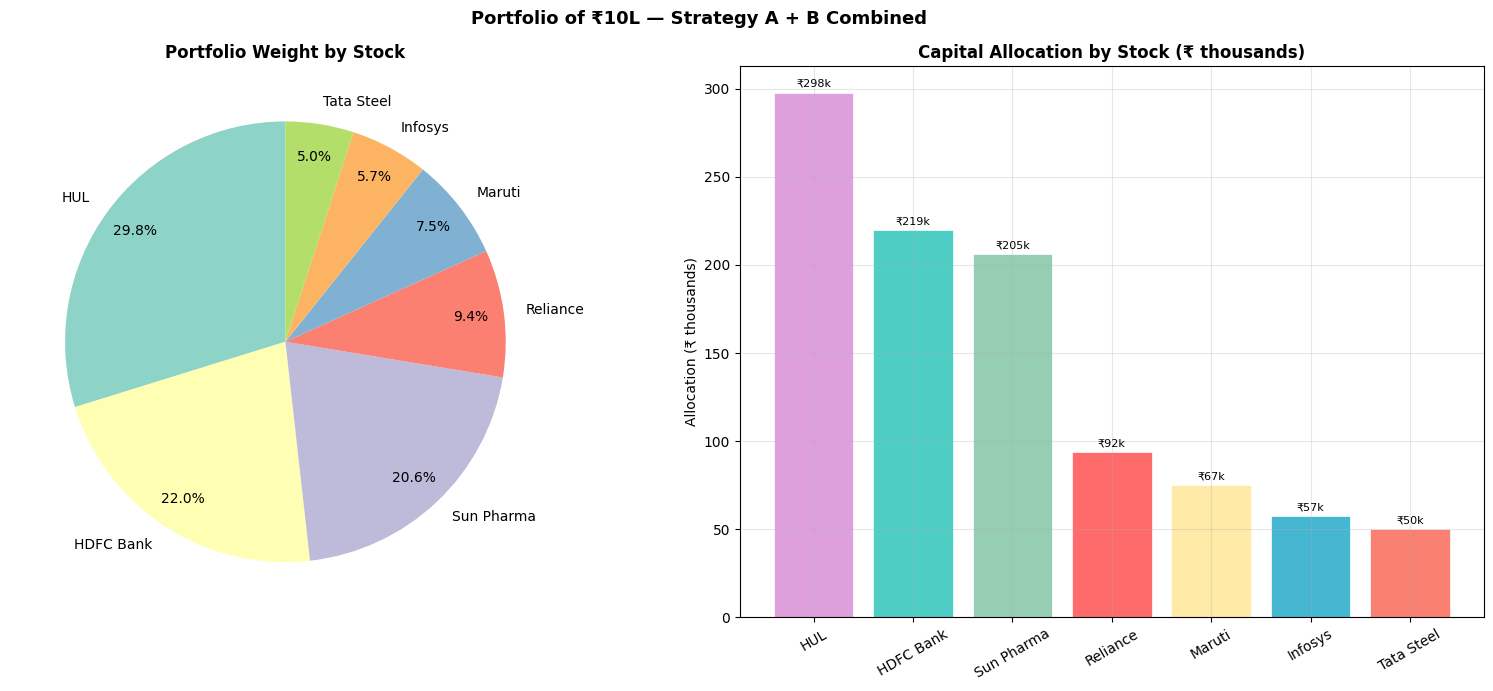

In [10]:
# ── PORTFOLIO VISUALIZATION ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart: allocation by stock
colors_pie = plt.cm.Set3.colors[:len(STOCKS)]
axes[0].pie(
    df_portfolio['Weight (%)'],
    labels    = df_portfolio['Stock'],
    autopct   = '%1.1f%%',
    colors    = colors_pie,
    startangle=90,
    pctdistance=0.85
)
axes[0].set_title('Portfolio Weight by Stock', fontweight='bold', fontsize=12)

# Bar chart: allocated ₹ by stock, colored by sector
sector_colors = {
    'Reliance'  : '#FF6B6B',   'HDFC Bank' : '#4ECDC4',
    'Infosys'   : '#45B7D1',   'Sun Pharma': '#96CEB4',
    'Maruti'    : '#FFEAA7',   'HUL'       : '#DDA0DD',
    'Tata Steel': '#FA8072'
}
bar_colors = [sector_colors.get(s, '#888') for s in df_portfolio['Stock']]

bars = axes[1].bar(df_portfolio['Stock'], df_portfolio['Allocation (₹)'] / 1000,
                   color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Capital Allocation by Stock (₹ thousands)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Allocation (₹ thousands)')
axes[1].tick_params(axis='x', rotation=30)

# Add ₹ labels on bars
for bar, row in zip(bars, df_portfolio.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'₹{row._7/1000:.0f}k', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'Portfolio of ₹{TOTAL_CAPITAL/100000:.0f}L — Strategy A + B Combined',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/05_portfolio_chart.png', dpi=150, bbox_inches='tight')
plt.show()